In [1]:
import mappy as mp
import random

# --- Your data generation (unchanged) ---
def create_test_data():
    bases = ['A', 'C', 'G', 'T']
    target_seq = "".join(random.choice(bases) for _ in range(500))

    q1 = "ACGACTAGCACGATAGCACTACGACAGC"
    q2 = "GACTTTCGACGACCTCTCTAGCAAAGCC"

    target_list = list(target_seq)
    target_list[100:100+len(q1)] = list(q1)
    target_list[350:350+len(q2)] = list(q2)

    # Returning distinct queries so we can distinguish 5' from 3'
    return "".join(target_list), [q1, q2]

ref_seq, flanks = create_test_data()
f5 = flanks[0]
f3 = flanks[1]

In [6]:
import parasail
import mappy as mp
import sys

# Define a simple namedtuple to mimic mappy's hit object for compatibility
from collections import namedtuple
Hit = namedtuple('Hit', ['r_st', 'r_en', 'strand', 'score'])

def get_best_hit_parasail(query_seq, target_seq):
    """
    Replaces mappy's get_best_hit using Smith-Waterman.
    Checks both strands and returns the best alignment.
    """
    best_score = -1
    best_hit = None
    
    # Define scoring (Match=2, Mismatch=-1, Open=4, Extend=2)
    # These are standard for noisy Nanopore alignment
    matrix = parasail.dnafull
    gap_open = 4
    gap_extend = 2

    # Check Forward and Reverse Complement
    strands = [(query_seq, 1), (mp.revcomp(query_seq), -1)]

    for seq, strand_val in strands:
        # Use local alignment (Smith-Waterman)
        result = parasail.sw_trace_striped_16(seq, target_seq, gap_open, gap_extend, matrix)
        
        # Parasail returns the end position of the alignment in the target
        # We can extract the start position from the traceback
        if result.score > best_score:
            # Simple heuristic: Score should be at least 2x length of flank
            # You can adjust this threshold based on noise levels
            if result.score > (len(query_seq) * 1.2): 
                best_score = result.score
                
                # Traceback gives us the target start and end
                # Note: parasail indices are 0-based
                best_hit = Hit(
                    r_st=result.end_ref - len(seq), # Approximation if traceback is messy
                    r_en=result.end_ref,
                    strand=strand_val,
                    score=result.score
                )
    # print(best_hit)
    return best_hit

def extract_region(read_seq, flank_5p, flank_3p):
    """
    Extracts sequence between two flanking sequences using Parasail.
    """
    h5 = get_best_hit_parasail(flank_5p, read_seq)
    h3 = get_best_hit_parasail(flank_3p, read_seq)

    if not h5 or not h3:
        return None, "Flanks not found"

    if h5.strand != h3.strand:
        return None, "Flank orientation mismatch"

    # Forward Strand
    if h5.strand == 1:
        if h5.r_en >= h3.r_st:
            return None, "Negative distance"
        return read_seq[h5.r_en : h3.r_st], "+"

    # Reverse Strand
    else:
        if h3.r_en >= h5.r_st:
            return None, "Negative distance (RC)"
        rc_segment = read_seq[h3.r_en : h5.r_st]
        return mp.revcomp(rc_segment), "-"

def process_fastq(fastq_path, bc_5p, bc_3p, ins_5p, ins_3p, min_length_fastq=3000):
    print(f"Processing: {fastq_path}")
    print("Read_ID\tBC_Status\tBC_Seq\tIns_Status\tIns_Seq")

    pairs = []

    i = 0
    for name, seq, qual in mp.fastx_read(fastq_path):
        if len(seq) < min_length_fastq:
            continue

        # print("\n\n")
        # print(seq)
        
        i += 1
        
        # Extract Barcode
        bc_seq, bc_status = extract_region(seq, bc_5p, bc_3p)
        
        # Extract Insert
        ins_seq, ins_status = extract_region(seq, ins_5p, ins_3p)

        bc_out = bc_seq if bc_seq else "NA"
        ins_out = ins_seq if ins_seq else "NA"

        pairs.append([bc_out, ins_out])

        # print(f"{name[:10]}...\t{bc_status}\t{bc_out[:20]}...\t{ins_status}\t{ins_out[:20]}...")

        # if i >= 10: 
        #     break

        if i % 1000 == 0:
            print(i)

    return pairs

if __name__ == "__main__":
    # Your flank sequences
    barcode_5p = "CAGCTGACGAGTCCCAAATAGGACGAgACGCGC".upper()
    barcode_3p = "cGTAAACTGGATCCGCAGGCCTCTGCTAGCTTGACTG".upper()
    insert_5p  = "CTTGGTGCCAGCTTATCA".upper()
    insert_3p  = "cctatgaagtgctctagtcaagtttaact".upper()

    fastq_file = "/Users/ogw/Downloads/ris_plasmids/no_sample_id/20251208_1553_MN41644_AYO707_6ec906fc/fastq_pass/combined.fastq.gz"  # Update with your path
    pairs = process_fastq(fastq_file, barcode_5p, barcode_3p, insert_5p, insert_3p)



Processing: /Users/ogw/Downloads/ris_plasmids/no_sample_id/20251208_1553_MN41644_AYO707_6ec906fc/fastq_pass/combined.fastq.gz
Read_ID	BC_Status	BC_Seq	Ins_Status	Ins_Seq
1000
2000


KeyboardInterrupt: 

In [45]:
import edlib
import mappy as mp
import sys
from collections import namedtuple, Counter, defaultdict

# --- CONFIGURATION ---
try:
    sys.set_int_max_str_digits(0) # Allow massive integers for inserts
except AttributeError:
    pass

DNA_TO_DIGITS = str.maketrans("ACGTN", "01234")
DIGITS_TO_DNA = {0: 'A', 1: 'C', 2: 'G', 3: 'T', 4: 'N'}

# --- COMPRESSION UTILS ---
def compress_dna(seq_str):
    if not seq_str: return None
    return int(seq_str.translate(DNA_TO_DIGITS), 5)

def decompress_dna(val, length):
    if val is None: return "NA"
    chars = []
    for _ in range(length):
        remainder = val % 5
        chars.append(DIGITS_TO_DNA[remainder])
        val //= 5
    return "".join(reversed(chars))

# --- ALIGNMENT LOGIC ---
Hit = namedtuple('Hit', ['r_st', 'r_en', 'strand', 'score'])

def get_best_hit_edlib(target_seq, query_seq, query_rc, threshold_pct=0.20):
    """
    Finds the best match considering both strands.
    Strictly returns None if:
    1. No match found within threshold.
    2. TIE: Forward score == Reverse Complement score.
    3. AMBIGUOUS: The winning strand has multiple locations with the same best score.
    """
    candidates = [(query_seq, 1), (query_rc, -1)]
    max_dist = int(len(query_seq) * threshold_pct)
    
    # Store valid hits from both strands
    # Structure: {'score': int, 'num_locs': int, 'loc': tuple, 'strand': int}
    valid_hits = []

    for seq, strand_val in candidates:
        result = edlib.align(seq, target_seq, mode="HW", task="locations", k=max_dist)
        score = result['editDistance']
        
        if score == -1: 
            continue
            
        valid_hits.append({
            'score': score,
            'num_locs': len(result['locations']),
            'loc': result['locations'][0], # We only need the first loc if it ends up being a unique winner
            'strand': strand_val
        })

    # --- DECISION LOGIC ---

    # 1. No hits at all?
    if not valid_hits:
        return None

    # 2. Sort hits by score (lowest distance is best)
    valid_hits.sort(key=lambda x: x['score'])
    best_hit = valid_hits[0]

    # 3. Check for Inter-Strand Tie (Forward vs Reverse)
    # If we have hits on both strands, check if their scores are identical
    if len(valid_hits) > 1:
        second_best = valid_hits[1]
        if best_hit['score'] == second_best['score']:
            return None # Fail: Tie between Forward and RC

    # 4. Check for Intra-Strand Ambiguity
    # Even if this strand is the clear winner, did it match multiple times in the read?
    if best_hit['num_locs'] > 1:
        return None # Fail: Multiple distinct locations found with the same best score

    # 5. We have a Clear Winner
    loc = best_hit['loc']
    return Hit(loc[0], loc[1] + 1, best_hit['strand'], best_hit['score'])

def extract_region(read_seq, f5, f5_rc, f3, f3_rc, max_len=10000):
    h5 = get_best_hit_edlib(read_seq, f5, f5_rc)
    h3 = get_best_hit_edlib(read_seq, f3, f3_rc)

    # Note: Ambiguous hits return None, so they will be caught here as "Missing"
    if not h5 or not h3:
        if not h5 and not h3: return None, "Both Flanks Missing"
        if not h5: return None, "5' Flank Missing"
        if not h3: return None, "3' Flank Missing"

    if h5.strand != h3.strand: return None, "Flank orientation mismatch"

    if h5.strand == 1:
        if h5.r_en >= h3.r_st: return None, "Overlap/Swap"
        dist = h3.r_st - h5.r_en
        if dist > max_len: return None, "Region too long"
        return read_seq[h5.r_en : h3.r_st], "PASS"
    else:
        if h3.r_en >= h5.r_st: return None, "RC Overlap/Swap"
        dist = h5.r_st - h3.r_en
        if dist > max_len: return None, "Region too long"
        return mp.revcomp(read_seq[h3.r_en : h5.r_st]), "PASS"

# --- MAIN PIPELINE ---
def process_fastq(fastq_path, bc_5p, bc_3p, ins_5p, ins_3p, min_length_fastq=1000):
    print(f"Processing: {fastq_path} (Inverted Index Mode)...", file=sys.stderr)
    
    bc_5p_rc = mp.revcomp(bc_5p)
    bc_3p_rc = mp.revcomp(bc_3p)
    ins_5p_rc = mp.revcomp(ins_5p)
    ins_3p_rc = mp.revcomp(ins_3p)

    bc_stats = Counter()
    ins_stats = Counter()
    total_processed = 0
    
    # --- NEW STORAGE STRUCTURE ---
    inserts_list = [] 
    barcode_map = defaultdict(list)
    
    for name, seq, qual in mp.fastx_read(fastq_path):
        if len(seq) < min_length_fastq: continue
        total_processed += 1
        
        bc_seq, bc_stat = extract_region(seq, bc_5p, bc_5p_rc, bc_3p, bc_3p_rc, max_len=100)
        ins_seq, ins_stat = extract_region(seq, ins_5p, ins_5p_rc, ins_3p, ins_3p_rc, max_len=10000)

        # Simplify Stats
        if bc_stat and "Region too long" in bc_stat: bc_stat = "Region too long"
        if ins_stat and "Region too long" in ins_stat: ins_stat = "Region too long"
        bc_stats[bc_stat] += 1
        ins_stats[ins_stat] += 1

        if total_processed % 5000 == 0:
            print(f"\rProcessed {total_processed} reads...", end="", file=sys.stderr)
        
        # --- STORAGE LOGIC ---
        if not bc_seq or not ins_seq:
            continue
        
        # 1. Compress Insert
        ins_comp = compress_dna(ins_seq)
        ins_len = len(ins_seq) if ins_seq else 0
        
        # 2. Append to Master List
        inserts_list.append((ins_comp, ins_len))
        
        # 3. Get the Index of the item we just added
        current_index = len(inserts_list) - 1
        
        # 4. Update Index (Dictionary)
        bc_key = bc_seq
        barcode_map[bc_key].append(current_index)
        

    print(f"\rDone. Processed {total_processed} reads.       ", file=sys.stderr)

    # Print Summary
    def print_table(title, stats):
        print(f"\n=== {title} SUMMARY ===")
        for k, v in stats.most_common():
            print(f"{k:<30} | {v:<8} | {(v/total_processed)*100:.1f}%")

    if total_processed > 0:
        print_table("BARCODE", bc_stats)
        print_table("INSERT", ins_stats)
        
    return inserts_list, barcode_map

if __name__ == "__main__":
    barcode_5p = "AATAGGACGAgACGCGC".upper()
    barcode_3p = "cGTAAACTGGATCCGC".upper()
    insert_5p  = "CTTGGTGCCAGCTTATCA".upper()
    insert_3p  = "cctatgaagtgctctagtcaagtttaact".upper()

    fastq_file = "/Users/ogw/Downloads/ris_plasmids/no_sample_id/20251208_1553_MN41644_AYO707_6ec906fc/fastq_pass/combined.fastq.gz" 
    fastq_file = '/Users/ogw/Library/CloudStorage/GoogleDrive-oscargwilkins@gmail.com/My Drive/UCL PhD/2025/plasmid_sequencing_results/21641/2025-10-30_01-47-43/downstream_risdiplam_array_pool/downstream_risdiplam_array_pool_raw.fastq.gz'
    
    # Run
    inserts, bc_index = process_fastq(fastq_file, barcode_5p, barcode_3p, insert_5p, insert_3p)

    print(f"\rTotal number of good barcode/insert pairs: {len(inserts)}")
    
    # --- DEMO: HOW TO USE THE NEW STRUCTURE ---
    print("\n--- DATA ACCESS DEMO ---")
    
    # 1. Find the most common barcode
    sorted_bcs = sorted(bc_index.items(), key=lambda item: len(item[1]), reverse=True)
    
    if sorted_bcs:
        top_bc, indices = sorted_bcs[0]
        print(f"Top Barcode: {top_bc} (Count: {len(indices)})")
        
        # 2. Get the first 3 inserts associated with this top barcode
        print(f"First 3 inserts for {top_bc}:")
        for idx in indices[:3]:
            comp_ins, ins_len = inserts[idx]
            raw_ins = decompress_dna(comp_ins, ins_len)
            print(f"  - Index {idx}: {raw_ins[:40]}...")

Processing: /Users/ogw/Library/CloudStorage/GoogleDrive-oscargwilkins@gmail.com/My Drive/UCL PhD/2025/plasmid_sequencing_results/21641/2025-10-30_01-47-43/downstream_risdiplam_array_pool/downstream_risdiplam_array_pool_raw.fastq.gz (Inverted Index Mode)...



=== BARCODE SUMMARY ===
PASS                           | 1335     | 79.3%
Both Flanks Missing            | 195      | 11.6%
5' Flank Missing               | 79       | 4.7%
3' Flank Missing               | 74       | 4.4%

=== INSERT SUMMARY ===
PASS                           | 1254     | 74.5%
3' Flank Missing               | 181      | 10.8%
Both Flanks Missing            | 175      | 10.4%
5' Flank Missing               | 55       | 3.3%
Overlap/Swap                   | 9        | 0.5%
RC Overlap/Swap                | 9        | 0.5%
Total number of good barcode/insert pairs: 1138

--- DATA ACCESS DEMO ---
Top Barcode: CCACTTTACTTCCA (Count: 4)
First 3 inserts for CCACTTTACTTCCA:
  - Index 76: GCGCGTCCTGGTAAGTCTCATGAGTAAGAAAGAGTAAGAG...
  - Index 323: GCGCGTCCTGGTAAGTCTCATGAGTAAGAAAGAGTAAGAG...
  - Index 748: GCGCGTCCTGGTAAGTCTCATGAGTAAGAAAGAGTAAGAG...


Done. Processed 1683 reads.       


In [39]:
    if sorted_bcs:
        top_bc, indices = sorted_bcs[1]
        print(f"Top Barcode: {top_bc} (Count: {len(indices)})")
        
        # 2. Get the first 3 inserts associated with this top barcode
        print(f"First 3 inserts for {top_bc}:")
        for idx in indices[:3]:
            comp_ins, ins_len = inserts[idx]
            raw_ins = decompress_dna(comp_ins, ins_len)
            print(f"  - Index {idx}: {raw_ins[:40]}...")

Top Barcode: TACTTCAATCACCT (Count: 16)
First 3 inserts for TACTTCAATCACCT:
  - Index 1803: GCGCGTCCTGGTAAGTAATCACTCACCTAAGAGTAAGATA...
  - Index 4177: NA...
  - Index 5735: GCACGTCCTGGTAAGTATTATGAGTAATGCACGCCTCGTG...


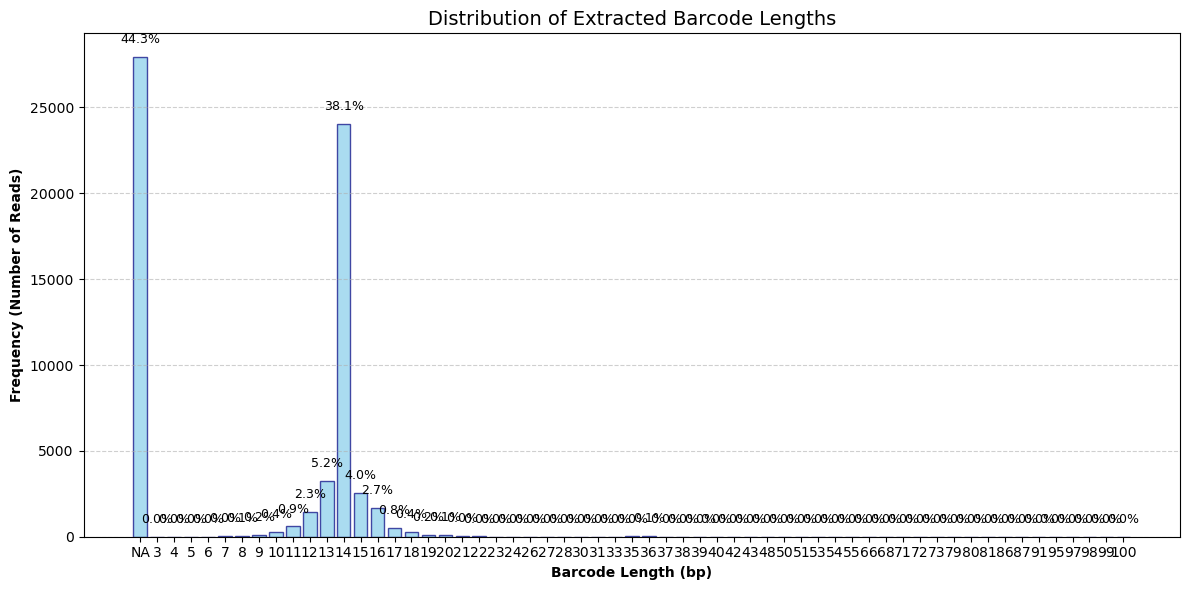

Length     Count      Percentage
------------------------------
NA         27919      44.26%
3          2          0.00%
4          1          0.00%
5          6          0.01%
6          9          0.01%
7          28         0.04%
8          44         0.07%
9          115        0.18%
10         258        0.41%
11         599        0.95%
12         1435       2.27%
13         3267       5.18%
14         24019      38.07%
15         2550       4.04%
16         1684       2.67%
17         522        0.83%
18         258        0.41%
19         103        0.16%
20         94         0.15%
21         29         0.05%
22         18         0.03%
23         4          0.01%
24         2          0.00%
26         1          0.00%
27         1          0.00%
28         1          0.00%
30         1          0.00%
31         1          0.00%
33         2          0.00%
35         13         0.02%
36         60         0.10%
37         7          0.01%
38         4          0.01%
39        

In [24]:
import matplotlib.pyplot as plt
from collections import Counter

def analyze_and_plot_barcodes(pairs):
    # 1. Extract lengths of the barcodes (index 0 of each pair)
    # If the barcode is "NA", we treat its length as 0 for sorting, 
    # but label it "NA" for the plot.
    lengths = []
    for p in pairs:
        bc = p[0]
        if bc == "NA":
            lengths.append(-1) # Use -1 to represent NA for easy sorting
        else:
            lengths.append(len(bc))

    # 2. Count frequencies
    counts = Counter(lengths)
    
    # 3. Sort by length (NA first, then 1, 2, 3...)
    sorted_lengths = sorted(counts.keys())
    
    # Prepare data for plotting
    labels = ["NA" if x == -1 else str(x) for x in sorted_lengths]
    values = [counts[x] for x in sorted_lengths]
    total = len(pairs)
    percentages = [(v / total) * 100 for v in values]

    # 4. Plotting
    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, values, color='skyblue', edgecolor='navy', alpha=0.7)

    # Add labels on top of bars
    for bar, pct in zip(bars, percentages):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (total*0.01), 
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.xlabel('Barcode Length (bp)', fontweight='bold')
    plt.ylabel('Frequency (Number of Reads)', fontweight='bold')
    plt.title('Distribution of Extracted Barcode Lengths', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Show plot
    plt.tight_layout()
    plt.show()

    # 5. Print a summary table
    print(f"{'Length':<10} {'Count':<10} {'Percentage':<10}")
    print("-" * 30)
    for l, v, p in zip(labels, values, percentages):
        print(f"{l:<10} {v:<10} {p:.2f}%")

# Usage:
analyze_and_plot_barcodes(pairs)

In [30]:
import edlib
import mappy as mp
import sys
from collections import namedtuple, Counter

# --- CRITICAL FIX FOR LONG INSERTS ---
# Python limits integer string conversion to 4300 digits by default.
# Your inserts are ~4600bp, which exceeds this. 
# We set the limit to 0 (no limit) to allow massive DNA-to-Int compression.
try:
    sys.set_int_max_str_digits(0)
except AttributeError:
    pass # Older Python versions don't have this limit

# --- THE CLEVER COMPRESSION ---
DNA_TO_DIGITS = str.maketrans("ACGTN", "01234")
DIGITS_TO_DNA = {0: 'A', 1: 'C', 2: 'G', 3: 'T', 4: 'N'}

def compress_dna(seq_str):
    """
    Converts a DNA string to a Base-5 integer.
    """
    if not seq_str: return None
    digits = seq_str.translate(DNA_TO_DIGITS)
    return int(digits, 5)

def decompress_dna(val, length):
    """
    Converts the Base-5 integer back to a DNA string.
    """
    if val is None: return "NA"
    chars = []
    # Extract digits in reverse order
    for _ in range(length):
        remainder = val % 5
        chars.append(DIGITS_TO_DNA[remainder])
        val //= 5
    return "".join(reversed(chars))

# --- END COMPRESSION ---

Hit = namedtuple('Hit', ['r_st', 'r_en', 'strand', 'score'])

def get_best_hit_edlib(target_seq, query_seq, query_rc, threshold_pct=0.20):
    best_hit = None
    best_ed = float('inf')
    candidates = [(query_seq, 1), (query_rc, -1)]
    max_dist = int(len(query_seq) * threshold_pct)

    for seq, strand_val in candidates:
        result = edlib.align(seq, target_seq, mode="HW", task="locations", k=max_dist)
        if result['editDistance'] == -1: continue 

        if result['editDistance'] < best_ed:
            best_ed = result['editDistance']
            loc = result['locations'][0]
            best_hit = Hit(loc[0], loc[1] + 1, strand_val, result['editDistance'])
            
    return best_hit

def extract_region(read_seq, f5, f5_rc, f3, f3_rc, max_len=10000):
    h5 = get_best_hit_edlib(read_seq, f5, f5_rc)
    h3 = get_best_hit_edlib(read_seq, f3, f3_rc)

    if not h5 or not h3:
        if not h5 and not h3: return None, "Both Flanks Missing"
        if not h5: return None, "5' Flank Missing"
        if not h3: return None, "3' Flank Missing"

    if h5.strand != h3.strand: return None, "Flank orientation mismatch"

    if h5.strand == 1:
        if h5.r_en >= h3.r_st: return None, "Overlap/Swap (Negative Dist)"
        dist = h3.r_st - h5.r_en
        if dist > max_len: return None, f"Region too long (> {max_len})"
        return read_seq[h5.r_en : h3.r_st], "PASS"
    else:
        if h3.r_en >= h5.r_st: return None, "RC Overlap/Swap (Negative Dist)"
        dist = h5.r_st - h3.r_en
        if dist > max_len: return None, f"Region too long (> {max_len})"
        return mp.revcomp(read_seq[h3.r_en : h5.r_st]), "PASS"

def print_summary(title, stats, total):
    print(f"\n=== {title} SUMMARY ===")
    print(f"{'Status':<35} | {'Count':<10} | {'Percent':<10}")
    print("-" * 65)
    for status, count in stats.most_common():
        pct = (count / total) * 100
        print(f"{status:<35} | {count:<10} | {pct:.1f}%")
    print("-" * 65)

def process_fastq(fastq_path, bc_5p, bc_3p, ins_5p, ins_3p, min_length_fastq=1000):
    print(f"Processing: {fastq_path} (Silent Mode with Compression)...", file=sys.stderr)
    
    bc_5p_rc = mp.revcomp(bc_5p)
    bc_3p_rc = mp.revcomp(bc_3p)
    ins_5p_rc = mp.revcomp(ins_5p)
    ins_3p_rc = mp.revcomp(ins_3p)

    bc_stats = Counter()
    ins_stats = Counter()
    total_processed = 0
    
    compressed_pairs = [] 
    
    for name, seq, qual in mp.fastx_read(fastq_path):
        if len(seq) < min_length_fastq: continue
        total_processed += 1
        
        bc_seq, bc_stat = extract_region(seq, bc_5p, bc_5p_rc, bc_3p, bc_3p_rc, max_len=100)
        ins_seq, ins_stat = extract_region(seq, ins_5p, ins_5p_rc, ins_3p, ins_3p_rc, max_len=10000)

        if bc_stat and "Region too long" in bc_stat: bc_stat = "Region too long"
        if ins_stat and "Region too long" in ins_stat: ins_stat = "Region too long"
        
        bc_stats[bc_stat] += 1
        ins_stats[ins_stat] += 1
        
        bc_comp = compress_dna(bc_seq)
        ins_comp = compress_dna(ins_seq)
        
        bc_len = len(bc_seq) if bc_seq else 0
        ins_len = len(ins_seq) if ins_seq else 0
        
        compressed_pairs.append( (bc_comp, bc_len, ins_comp, ins_len) )
        
        if total_processed % 5000 == 0:
            print(f"\rProcessed {total_processed} reads...", end="", file=sys.stderr)

    print(f"\rDone! Processed {total_processed} reads.      ", file=sys.stderr)

    if total_processed > 0:
        print_summary("BARCODE", bc_stats, total_processed)
        print_summary("INSERT", ins_stats, total_processed)
    else:
        print("\nNo reads processed.", file=sys.stderr)
        
    return compressed_pairs

if __name__ == "__main__":
    barcode_5p = "AATAGGACGAgACGCGC".upper()
    barcode_3p = "cGTAAACTGGATCCGC".upper()
    insert_5p  = "CTTGGTGCCAGCTTATCA".upper()
    insert_3p  = "cctatgaagtgctctagtcaagtttaact".upper()

    fastq_file = "/Users/ogw/Downloads/ris_plasmids/no_sample_id/20251208_1553_MN41644_AYO707_6ec906fc/fastq_pass/combined.fastq.gz" 
    
    data = process_fastq(fastq_file, barcode_5p, barcode_3p, insert_5p, insert_3p)
    
    if data:
        print("\n--- Decompression Check (First Result) ---")
        bc_int, bc_len, ins_int, ins_len = data[0]
        final_bc = decompress_dna(bc_int, bc_len)
        final_ins = decompress_dna(ins_int, ins_len)
        print(f"Barcode: {final_bc}")
        print(f"Insert:  {final_ins[:50]}... (truncated)")

Processing: /Users/ogw/Downloads/ris_plasmids/no_sample_id/20251208_1553_MN41644_AYO707_6ec906fc/fastq_pass/combined.fastq.gz (Silent Mode with Compression)...
Processed 60000 reads...


=== BARCODE SUMMARY ===
Status                              | Count      | Percent   
-----------------------------------------------------------------
PASS                                | 33126      | 52.5%
Both Flanks Missing                 | 15087      | 23.9%
3' Flank Missing                    | 8595       | 13.6%
5' Flank Missing                    | 5130       | 8.1%
Flank orientation mismatch          | 598        | 0.9%
RC Overlap/Swap (Negative Dist)     | 254        | 0.4%
Overlap/Swap (Negative Dist)        | 217        | 0.3%
Region too long                     | 79         | 0.1%
-----------------------------------------------------------------

=== INSERT SUMMARY ===
Status                              | Count      | Percent   
-----------------------------------------------------------------
PASS                                | 37671      | 59.7%
Both Flanks Missing                 | 14238      | 22.6%
3' Flank Missing                    | 8179       | 13.0%
5' Flan

Done! Processed 63086 reads.      


In [37]:
        bc_int, bc_len, ins_int, ins_len = data[2]
        final_bc = decompress_dna(bc_int, bc_len)
        final_ins = decompress_dna(ins_int, ins_len)
        print(f"Barcode: {final_bc}")
        print(f"Insert:  {final_ins[:50]}... (truncated)")

Barcode: CAGACTCATCCATC
Insert:  TGGTACGGAATAGTCGTTACAGCTCCGGCGCATCCTGGTAAGTAATCACT... (truncated)


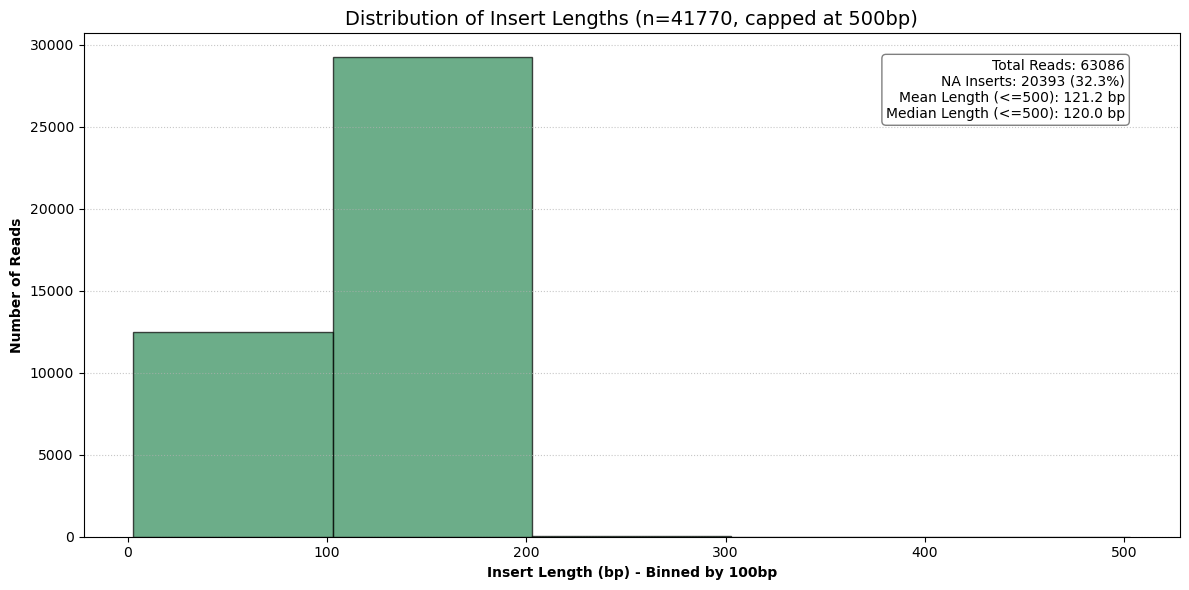

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_insert_hist(pairs, bin_size=50):
    """
    Plots a histogram of insert lengths, grouped into bins, ignoring lengths > 500.
    
    Args:
        pairs: List of [barcode, insert]
        bin_size: The width of the blocks (e.g., 50bp)
    """
    # 1. Extract lengths for non-NA inserts and filter out those > 500
    insert_lengths = [len(p[1]) for p in pairs if p[1] != "NA" and len(p[1]) <= 500]
    na_count = sum(1 for p in pairs if p[1] == "NA")
    total = len(pairs)

    if not insert_lengths:
        print("No valid inserts <= 500bp found to plot.")
        return

    # 2. Determine bin range
    min_len = min(insert_lengths)
    # We set max_len to 500 to ensure the bins cover the full range up to the limit
    max_len = 500 
    
    # Create bins from min to 500, spaced by bin_size
    bins = np.arange(min_len, max_len + bin_size, bin_size)

    # 3. Plotting
    plt.figure(figsize=(12, 6))
    
    # Use hist() to automatically lump lengths into blocks
    n, bins, patches = plt.hist(insert_lengths, bins=bins, 
                                color='seagreen', edgecolor='black', alpha=0.7)

    # 4. Styling
    plt.title(f'Distribution of Insert Lengths (n={len(insert_lengths)}, capped at 500bp)', fontsize=14)
    plt.xlabel(f'Insert Length (bp) - Binned by {bin_size}bp', fontweight='bold')
    plt.ylabel('Number of Reads', fontweight='bold')
    
    # Add a text box with summary stats (calculated from filtered data)
    stats_text = (f"Total Reads: {total}\n"
                  f"NA Inserts: {na_count} ({na_count/total:.1%})\n"
                  f"Mean Length (<=500): {np.mean(insert_lengths):.1f} bp\n"
                  f"Median Length (<=500): {np.median(insert_lengths):.1f} bp")
    
    plt.gca().text(0.95, 0.95, stats_text, transform=plt.gca().transAxes,
                   fontsize=10, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Usage:
plot_insert_hist(pairs, bin_size=100)

In [20]:
import numpy as np
from numba import jit, uint64, int64, int32

# Mapping for DNA: A=0, C=1, G=2, T=3, N=4 (or others)
@jit(nopython=True)
def seq_to_ints(seq_str):
    """Converts a DNA string to a numpy array of integers."""
    n = len(seq_str)
    res = np.empty(n, dtype=np.int8)
    for i in range(n):
        c = seq_str[i]
        if c == 'A' or c == 'a': res[i] = 0
        elif c == 'C' or c == 'c': res[i] = 1
        elif c == 'G' or c == 'g': res[i] = 2
        elif c == 'T' or c == 't': res[i] = 3
        else: res[i] = 4 # Treat N and others as mismatch
    return res

@jit(nopython=True)
def get_rev_comp_ints(ints):
    """Returns the Reverse Complement of the integer sequence."""
    n = len(ints)
    res = np.empty(n, dtype=np.int8)
    for i in range(n):
        val = ints[n - 1 - i]
        if val == 0: res[i] = 3   # A->T
        elif val == 1: res[i] = 2 # C->G
        elif val == 2: res[i] = 1 # G->C
        elif val == 3: res[i] = 0 # T->A
        else: res[i] = 4
    return res

@jit(nopython=True)
def myers_search_64(t_seq, p_seq, max_dist):
    """
    Bit-Parallel Myers Algorithm (Edlib style) for patterns <= 64bp.
    Returns: (best_score, best_end_index)
    """
    m = len(p_seq)
    n = len(t_seq)
    
    # 1. Precompute Pattern Bitmasks (Peq)
    # peq[char] has a bit set at index j if pattern[j] == char
    peq = np.zeros(5, dtype=np.uint64)
    for i in range(m):
        # Set the i-th bit for the character p_seq[i]
        peq[p_seq[i]] |= (uint64(1) << uint64(i))

    # 2. Initialize Bit Vectors
    # VP: Vertical Positive (delta +1), VN: Vertical Negative (delta -1)
    VP = ~uint64(0) # All 1s
    VN = uint64(0)
    
    score = m
    best_score = m + 1
    best_end = -1
    
    # Mask to ensure we don't overflow the pattern length
    mask_msb = uint64(1) << uint64(m - 1)

    # 3. Scan the Target (Long Read)
    for j in range(n):
        # Fetch char from text
        char_code = t_seq[j]
        if char_code > 4: char_code = 4 # Safety
        
        # Myers' Formula Step
        X = peq[char_code] | VN
        D0 = ((VP + (X & VP)) ^ VP) | X
        HN = VP & D0
        HP = VN | ~(VP | D0)
        
        X = HP << uint64(1)
        VN = X & D0
        VP = (HN << uint64(1)) | ~(X | D0)
        
        # Update Score (Edit Distance at current column)
        # If HN has MSB set, score decreases. If HP has MSB set, score increases.
        if (HN & mask_msb):
            score -= 1
        if (HP & mask_msb):
            score += 1
            
        # Check if this is the best hit so far
        if score < best_score:
            best_score = score
            best_end = j
            
            # Optimization: If perfect match found, you could break, 
            # but for best alignment in error-prone reads, we usually continue 
            # or break if score == 0.
            if score == 0:
                break

    return best_score, best_end

@jit(nopython=True)
def simple_dp_traceback(t_seq, p_seq):
    """
    Simple DP to find the exact start position given the end region.
    Runs backwards from the end to determine length.
    """
    m = len(p_seq)
    n = len(t_seq)
    
    # Create small DP table (m+1) x (n+1)
    # Since we are just refining a small window, this is fast.
    dp = np.zeros((m + 1, n + 1), dtype=np.int32)
    
    # Initialize first row/col
    for i in range(m + 1): dp[i, 0] = i
    for j in range(n + 1): dp[0, j] = 0 # Free gaps at start (local)
    
    # Fill DP
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if p_seq[i-1] == t_seq[j-1] else 1
            dp[i, j] = min(dp[i-1, j] + 1,      # Deletion
                           dp[i, j-1] + 1,      # Insertion
                           dp[i-1, j-1] + cost) # Match/Sub
                           
    # Traceback from max J in last row to find where we hit zero (or min)
    # But actually, since we reversed the strings, the "Start" of the alignment
    # is the "End" of this DP.
    
    # Find min score in last row
    min_score = 99999
    best_j = 0
    for j in range(n + 1):
        if dp[m, j] <= min_score:
            min_score = dp[m, j]
            best_j = j
            
    return best_j # This is the length of the match in the target

@jit(nopython=True)
def find_primer_numba(read_ints, primer_ints, max_dist):
    """
    Main driver function.
    1. Runs Bit-Parallel forward scan to find Best End.
    2. Cuts a window and runs Backward DP to find Best Start.
    """
    m = len(primer_ints)
    
    # --- Forward Search ---
    score, end_idx = myers_search_64(read_ints, primer_ints, max_dist)
    
    if score > max_dist:
        return -1, -1, score # No hit
    
    # --- Refine Start Position ---
    # We define a window in the read ending at 'end_idx'
    # The window size should be roughly len(primer) + some buffer for indels
    window_size = m + (m // 2) + 10
    start_search_idx = end_idx - window_size
    if start_search_idx < 0: start_search_idx = 0
    
    # Extract the target window segment and REVERSE it
    t_segment = read_ints[start_search_idx : end_idx + 1]
    t_rev = t_segment[::-1] # Reverse in numpy
    
    # Reverse the primer
    p_rev = primer_ints[::-1]
    
    # Run simple alignment to find length
    match_len = simple_dp_traceback(t_rev, p_rev)
    
    # Calculate absolute start
    # The match ends at end_idx. The length is match_len.
    start_idx = end_idx - match_len + 1
    
    return start_idx, end_idx, score

def find_best_primer_hit(read_seq, primer_seq, threshold=0.3):
    """
    Python wrapper to handle encoding and strands.
    """
    if len(primer_seq) > 64:
        raise ValueError("Primer must be <= 64bp for this optimization.")
        
    read_ints = seq_to_ints(read_seq)
    primer_ints = seq_to_ints(primer_seq)
    primer_rc_ints = get_rev_comp_ints(primer_ints)
    
    max_dist = int(len(primer_seq) * threshold)
    
    # Check Forward Strand
    s1, e1, score1 = find_primer_numba(read_ints, primer_ints, max_dist)
    
    # Check Reverse Strand
    s2, e2, score2 = find_primer_numba(read_ints, primer_rc_ints, max_dist)
    
    # Compare results
    hit1_valid = (s1 != -1)
    hit2_valid = (s2 != -1)
    
    if hit1_valid and hit2_valid:
        if score1 <= score2:
            return {'start': s1, 'end': e1, 'score': score1, 'strand': '+'}
        else:
            return {'start': s2, 'end': e2, 'score': score2, 'strand': '-'}
            
    elif hit1_valid:
        return {'start': s1, 'end': e1, 'score': score1, 'strand': '+'}
        
    elif hit2_valid:
        return {'start': s2, 'end': e2, 'score': score2, 'strand': '-'}
        
    return None

In [21]:
import mappy as mp
import sys
import numpy as np
from collections import namedtuple
from numba import jit, uint64, int64, int32

# ... [PASTE YOUR NUMBA FUNCTIONS HERE: seq_to_ints, get_rev_comp_ints, myers_search_64, simple_dp_traceback, find_primer_numba, find_best_primer_hit] ...

# Define Hit object
Hit = namedtuple('Hit', ['r_st', 'r_en', 'strand', 'trans_strand', 'score'])

def get_best_hit_numba(query_seq, target_seq, threshold_pct=0.30):
    """
    Wrapper to adapt the Numba function output to the Hit namedtuple 
    expected by the rest of the pipeline.
    """
    # Call the Numba wrapper you wrote (find_best_primer_hit)
    # Note: Your wrapper handles both strands and int conversion internally.
    result = find_best_primer_hit(target_seq, query_seq, threshold=threshold_pct)

    if result is None:
        return None

    # Convert the Numba result dict back to the Hit namedtuple
    # Your Numba code returns strand as '+' or '-'. 
    # The original logic used 1 for '+' and -1 for '-'.
    strand_val = 1 if result['strand'] == '+' else -1
    
    return Hit(
        r_st=result['start'],
        r_en=result['end'] + 1, # Numba end was inclusive, Python slice needs exclusive
        strand=strand_val,
        trans_strand=result['strand'],
        score=result['score']
    )

def extract_region(read_seq, flank_5p, flank_3p):
    """
    Extracts sequence between two flanking sequences using the Numba implementation.
    """
    # 1. Find the flanks (Swapped function call)
    h5 = get_best_hit_numba(flank_5p, read_seq)
    h3 = get_best_hit_numba(flank_3p, read_seq)

    if not h5 or not h3:
        return None, "Flanks not found"

    # 2. Check Orientation Consistency
    if h5.strand != h3.strand:
        return None, "Flank orientation mismatch"

    # 3. Extract based on strand
    # Forward Strand (Both matched as Forward)
    if h5.strand == 1:
        # h5 should appear BEFORE h3
        if h5.r_en >= h3.r_st:
            return None, "Negative distance (Overlap/Swap)"
        
        # Extract the middle
        return read_seq[h5.r_en : h3.r_st], "+"

    # Reverse Strand (Both matched as Reverse Complement)
    else:
        # If the read is RC, the RC(5'BC) appears at the END of the read
        # and RC(3'BC) appears at the START of the read.
        if h3.r_en >= h5.r_st:
            return None, "Negative distance (RC Overlap/Swap)"
            
        rc_segment = read_seq[h3.r_en : h5.r_st]
        return mp.revcomp(rc_segment), "-"

def process_fastq(fastq_path, bc_5p, bc_3p, ins_5p, ins_3p, min_length_fastq=1000):
    print(f"Processing: {fastq_path}")
    print("Read_ID\tBC_Status\tBC_Seq\tIns_Status\tIns_Seq")

    pairs = []
    i = 0
    
    # Use mappy to read fastq (fast!)
    for name, seq, qual in mp.fastx_read(fastq_path):
        if len(seq) < min_length_fastq:
            continue

        i += 1
        
        # Extract Barcode
        bc_seq, bc_status = extract_region(seq, bc_5p, bc_3p)
        
        # Extract Insert
        ins_seq, ins_status = extract_region(seq, ins_5p, ins_3p)

        bc_out = bc_seq if bc_seq else "NA"
        ins_out = ins_seq if ins_seq else "NA"

        pairs.append([bc_out, ins_out])
        
        # Optional: Print progress
        if i % 1000 == 0:
            print(f"Processed {i} reads...", file=sys.stderr)

    return pairs

if __name__ == "__main__":
    # Your flank sequences
    barcode_5p = "AATAGGACGAgACGCGC".upper()
    barcode_3p = "cGTAAACTGGATCCGC".upper()
    insert_5p  = "CTTGGTGCCAGCTTATCA".upper()
    insert_3p  = "cctatgaagtgctctagtcaagtttaact".upper()

    fastq_file = "/Users/ogw/Downloads/ris_plasmids/no_sample_id/20251208_1553_MN41644_AYO707_6ec906fc/fastq_pass/combined.fastq.gz" 
    pairs = process_fastq(fastq_file, barcode_5p, barcode_3p, insert_5p, insert_3p)

Processing: /Users/ogw/Downloads/ris_plasmids/no_sample_id/20251208_1553_MN41644_AYO707_6ec906fc/fastq_pass/combined.fastq.gz
Read_ID	BC_Status	BC_Seq	Ins_Status	Ins_Seq


Processed 1000 reads...
Processed 2000 reads...
Processed 3000 reads...
Processed 4000 reads...
Processed 5000 reads...
Processed 6000 reads...
Processed 7000 reads...
Processed 8000 reads...
Processed 9000 reads...
Processed 10000 reads...
Processed 11000 reads...
Processed 12000 reads...
Processed 13000 reads...
Processed 14000 reads...
Processed 15000 reads...
Processed 16000 reads...
Processed 17000 reads...
Processed 18000 reads...
Processed 19000 reads...
Processed 20000 reads...
Processed 21000 reads...
Processed 22000 reads...
Processed 23000 reads...
Processed 24000 reads...
Processed 25000 reads...
Processed 26000 reads...
Processed 27000 reads...
Processed 28000 reads...
Processed 29000 reads...
Processed 30000 reads...
Processed 31000 reads...
Processed 32000 reads...
Processed 33000 reads...
Processed 34000 reads...
Processed 35000 reads...
Processed 36000 reads...
Processed 37000 reads...
Processed 38000 reads...
Processed 39000 reads...
Processed 40000 reads...
Processed

In [ ]:
for pair in pairs:
    bc = pair[0]
    insert = pair[1]
    if bc is None or insert is None:
        continue

    print("")
    print(len(bc))
    print(len(insert))

In [36]:
matrix = parasail.dnafull
result = parasail.sw_trace_striped_16("ACGACTGACACTGACACGACATCGACACTTCTCTCGCGGCGCG", "ACGACTGACACTGCTTCTCTCGCGGCGCG", 4, 0, matrix)
print(f"Score with Ns: {result.score}")

Score with Ns: 141
